# ShelfSight — YOLOv8s Shelf Detection Model
### AI Lab Project | CSC-233 | BNU Spring 2026
**Student:** Ibrahim Zahid | **Role:** Image Collection + Model 2 (YOLOv8s)

---

## How to use this notebook
- **First time:** Run all cells top to bottom to train the model
- **After every session restart:** Only run the ONE cell marked 🔄 then skip to Step 11

---

## 🔄 SESSION RESTART? RUN THIS CELL FIRST — THEN SKIP TO STEP 11

In [1]:
# ═══════════════════════════════════════════════════════
# RUN THIS AFTER EVERY RESTART — install, import, load model
# ═══════════════════════════════════════════════════════

%pip install ultralytics roboflow --quiet

from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO
from pathlib import Path
import yaml, numpy as np, matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display
import pandas as pd

# ── Key paths ──────────────────────────────────────────
BEST_MODEL  = "/content/drive/MyDrive/ShelfSight/YOLOv8s_Model2_Ibrahim/weights/best.pt"
RESULTS_DIR = "/content/drive/MyDrive/ShelfSight/YOLOv8s_Model2_Ibrahim"
IMAGE_SIZE  = 640
training_time_mins = 0   # set to 0 if skipping training

# ── Re-download dataset (needed for data.yaml) ─────────
from roboflow import Roboflow
rf = Roboflow(api_key="G2NmxkC2Za5dtJ47ID3a")
project = rf.workspace("rf20-vl").project("soda-bottles-haga")
version = project.version(1)
dataset = version.download("yolov8")

yaml_files = list(Path(".").rglob("data.yaml"))
DATA_YAML  = str(yaml_files[0])

# ── Load trained model ─────────────────────────────────
if Path(BEST_MODEL).exists():
    trained_model = YOLO(BEST_MODEL)
    print("=" * 50)
    print("Everything loaded. Skip to Step 11 now.")
    print("=" * 50)
    print(f"Model    : {BEST_MODEL}")
    print(f"data.yaml: {DATA_YAML}")
    print(f"Classes  : {trained_model.names}")
else:
    print("=" * 50)
    print("best.pt not found in Drive yet.")
    print("Run Phase 3 (training) first, then restart.")
    print("=" * 50)
    print(f"Expected path: {BEST_MODEL}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 85.4 MB/s eta 0:00:00
Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to soda-bottles-haga-1 in yolov8:: 100%|██████████| 4510/4510 [00:02<00:00, 1917.21it/s]


best.pt not found in Drive yet.
Run Phase 3 (training) first, then restart.
Expected path: /content/drive/MyDrive/ShelfSight/YOLOv8s_Model2_Ibrahim/weights/best.pt


---
## Phase 1 — Setup
> ⏭️ SKIP if you already ran the 🔄 restart cell above.

In [ ]:
%pip install ultralytics roboflow --quiet

from google.colab import drive
drive.mount('/content/drive')

import ultralytics
ultralytics.checks()

In [ ]:
import os, yaml, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as patches, pandas as pd
from pathlib import Path
from ultralytics import YOLO
from PIL import Image
from IPython.display import Image as IPImage, display

print("Libraries imported.")

---
## Phase 2 — Download Dataset
> ⏭️ SKIP if you already ran the 🔄 restart cell above.

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="G2NmxkC2Za5dtJ47ID3a")
project = rf.workspace("rf20-vl").project("soda-bottles-haga")
version = project.version(1)
dataset = version.download("yolov8")
print("Downloaded to:", dataset.location)

In [ ]:
yaml_files = list(Path(".").rglob("data.yaml"))
if not yaml_files:
    raise FileNotFoundError("data.yaml not found.")
DATA_YAML = str(yaml_files[0])
print("data.yaml:", DATA_YAML)
with open(DATA_YAML) as f:
    print(f.read())

In [ ]:
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)
class_names = cfg.get("names", [])
print("Classes:", class_names)

train_labels = Path(DATA_YAML).parent / "train" / "labels"
class_counts = {i: 0 for i in range(len(class_names))}
if train_labels.exists():
    for lf in train_labels.glob("*.txt"):
        with open(lf) as f:
            for line in f:
                p = line.strip().split()
                if p: class_counts[int(p[0])] += 1

total = sum(class_counts.values())
print(f"Total boxes: {total:,}")
for cid, cnt in class_counts.items():
    name = class_names[cid] if cid < len(class_names) else f"cls{cid}"
    pct  = cnt / total * 100 if total else 0
    print(f"  {name:<20}: {cnt:,}  ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 3))
names  = [class_names[i] if i < len(class_names) else f"cls{i}" for i in class_counts]
counts = list(class_counts.values())
ax.bar(names, counts, color=["#1D9E75","#378ADD","#EF9F27"])
ax.set_title("Class distribution — should match Shameer's")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

---
## Phase 3 — Train YOLOv8s (Model 2)
> ⛔ SKIP if model already trained and saved to Drive.
> Only run if training for the first time.

### Step 6 — Model size comparison (run this, no training happens)

In [ ]:
# Just shows the difference — no training, safe to run
model_n = YOLO("yolov8n.pt")
model_s = YOLO("yolov8s.pt")

params_n = sum(p.numel() for p in model_n.model.parameters())
params_s = sum(p.numel() for p in model_s.model.parameters())

print("Model size comparison:")
print(f"  YOLOv8n (Shameer): {params_n:,} parameters")
print(f"  YOLOv8s (Ibrahim): {params_s:,} parameters")
print(f"  {params_s/params_n:.1f}x larger — should give better accuracy")

del model_n

### Step 7 — Train the model
> ⛔ SKIP if already trained. Takes 30–60 minutes.

In [ ]:
# ⛔ SKIP THIS CELL if model is already in Drive
import time
start_time = time.time()

IMAGE_SIZE = 640
BATCH_SIZE = 16
LR         = 0.01

model = YOLO("yolov8s.pt")

model.train(
    data    = DATA_YAML,
    epochs  = 50,
    imgsz   = IMAGE_SIZE,
    batch   = BATCH_SIZE,
    lr0     = LR,
    patience= 10,
    save    = True,
    plots   = True,
    project = "/content/drive/MyDrive/ShelfSight",
    name    = "YOLOv8s_Model2_Ibrahim",
)

training_time_mins = (time.time() - start_time) / 60
BEST_MODEL  = "/content/drive/MyDrive/ShelfSight/YOLOv8s_Model2_Ibrahim/weights/best.pt"
RESULTS_DIR = "/content/drive/MyDrive/ShelfSight/YOLOv8s_Model2_Ibrahim"
IMAGE_SIZE  = 640

print(f"Training complete! Time: {training_time_mins:.1f} minutes")
print(f"Saved to: {BEST_MODEL}")

---
## Phase 4 — Evaluate the Model
> ✅ Start here after running the 🔄 restart cell.

### Step 8 — Load the trained model

In [4]:
trained_model = YOLO(BEST_MODEL)
print("Loaded:", BEST_MODEL)
print("Classes:", trained_model.names)

Loaded: /content/drive/MyDrive/ShelfSight/YOLOv8s_Model2_Ibrahim/weights/best.pt
Classes: {0: 'coca-cola', 1: 'fanta', 2: 'sprite'}


### Step 9 — Evaluate on the test set

In [5]:
metrics = trained_model.val(
    data    = DATA_YAML,
    split   = "test",
    imgsz   = IMAGE_SIZE,
    verbose = True,
)

map50     = metrics.box.map50
map5095   = metrics.box.map
precision = metrics.box.mp
recall    = metrics.box.mr

print("\n" + "="*55)
print("MODEL 2 (YOLOv8s) — IBRAHIM'S FINAL RESULTS")
print("="*55)
print(f"  mAP50     : {map50*100:.2f}%")
print(f"  mAP50-95  : {map5095*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print("="*55)

if map50 >= 0.70:   grade = "Excellent"
elif map50 >= 0.50: grade = "Good"
elif map50 >= 0.30: grade = "Decent"
else:               grade = "Needs improvement"
print(f"  Grade     : {grade}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2738.3±533.4 MB/s, size: 262.9 KB)
val: Scanning /content/soda-bottles-haga-1/test/labels... 226 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 226/226 1.4Kit/s 0.2s
val: New cache created: /content/soda-bottles-haga-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.5it/s 9.9s
                   all        226       5555      0.938      0.927      0.946      0.539
             coca-cola        220       1829      0.936       0.92       0.94      0.533
                 fanta        223       1832      0.952      0.935      0.957      0.539
                sprite        219       1894      0.926      0.926      0.941      0.546
Speed: 2.4ms preprocess, 6.3ms inference, 0.0ms loss, 3.1ms 

### Step 10 — Plot training curves (from Drive)

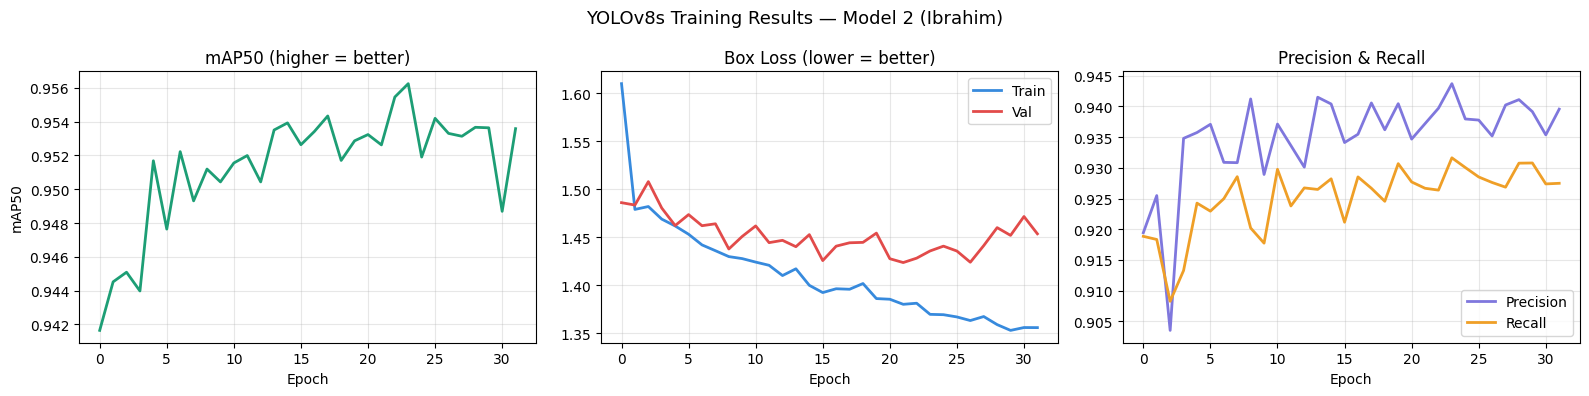

In [6]:
results_csv = Path(RESULTS_DIR) / "results.csv"

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    if "metrics/mAP50(B)" in df.columns:
        axes[0].plot(df["metrics/mAP50(B)"], color="#1D9E75", linewidth=2)
        axes[0].set_title("mAP50 (higher = better)")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("mAP50")
        axes[0].grid(alpha=0.3)

    if "train/box_loss" in df.columns:
        axes[1].plot(df["train/box_loss"], label="Train", color="#378ADD", linewidth=2)
        if "val/box_loss" in df.columns:
            axes[1].plot(df["val/box_loss"], label="Val", color="#E24B4A", linewidth=2)
        axes[1].set_title("Box Loss (lower = better)")
        axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

    if "metrics/precision(B)" in df.columns:
        axes[2].plot(df["metrics/precision(B)"], label="Precision", color="#7F77DD", linewidth=2)
        if "metrics/recall(B)" in df.columns:
            axes[2].plot(df["metrics/recall(B)"], label="Recall", color="#EF9F27", linewidth=2)
        axes[2].set_title("Precision & Recall")
        axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle("YOLOv8s Training Results — Model 2 (Ibrahim)", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print(f"results.csv not found at: {results_csv}")

### Step 11 — Show confusion matrix and plots


--- confusion_matrix.png ---


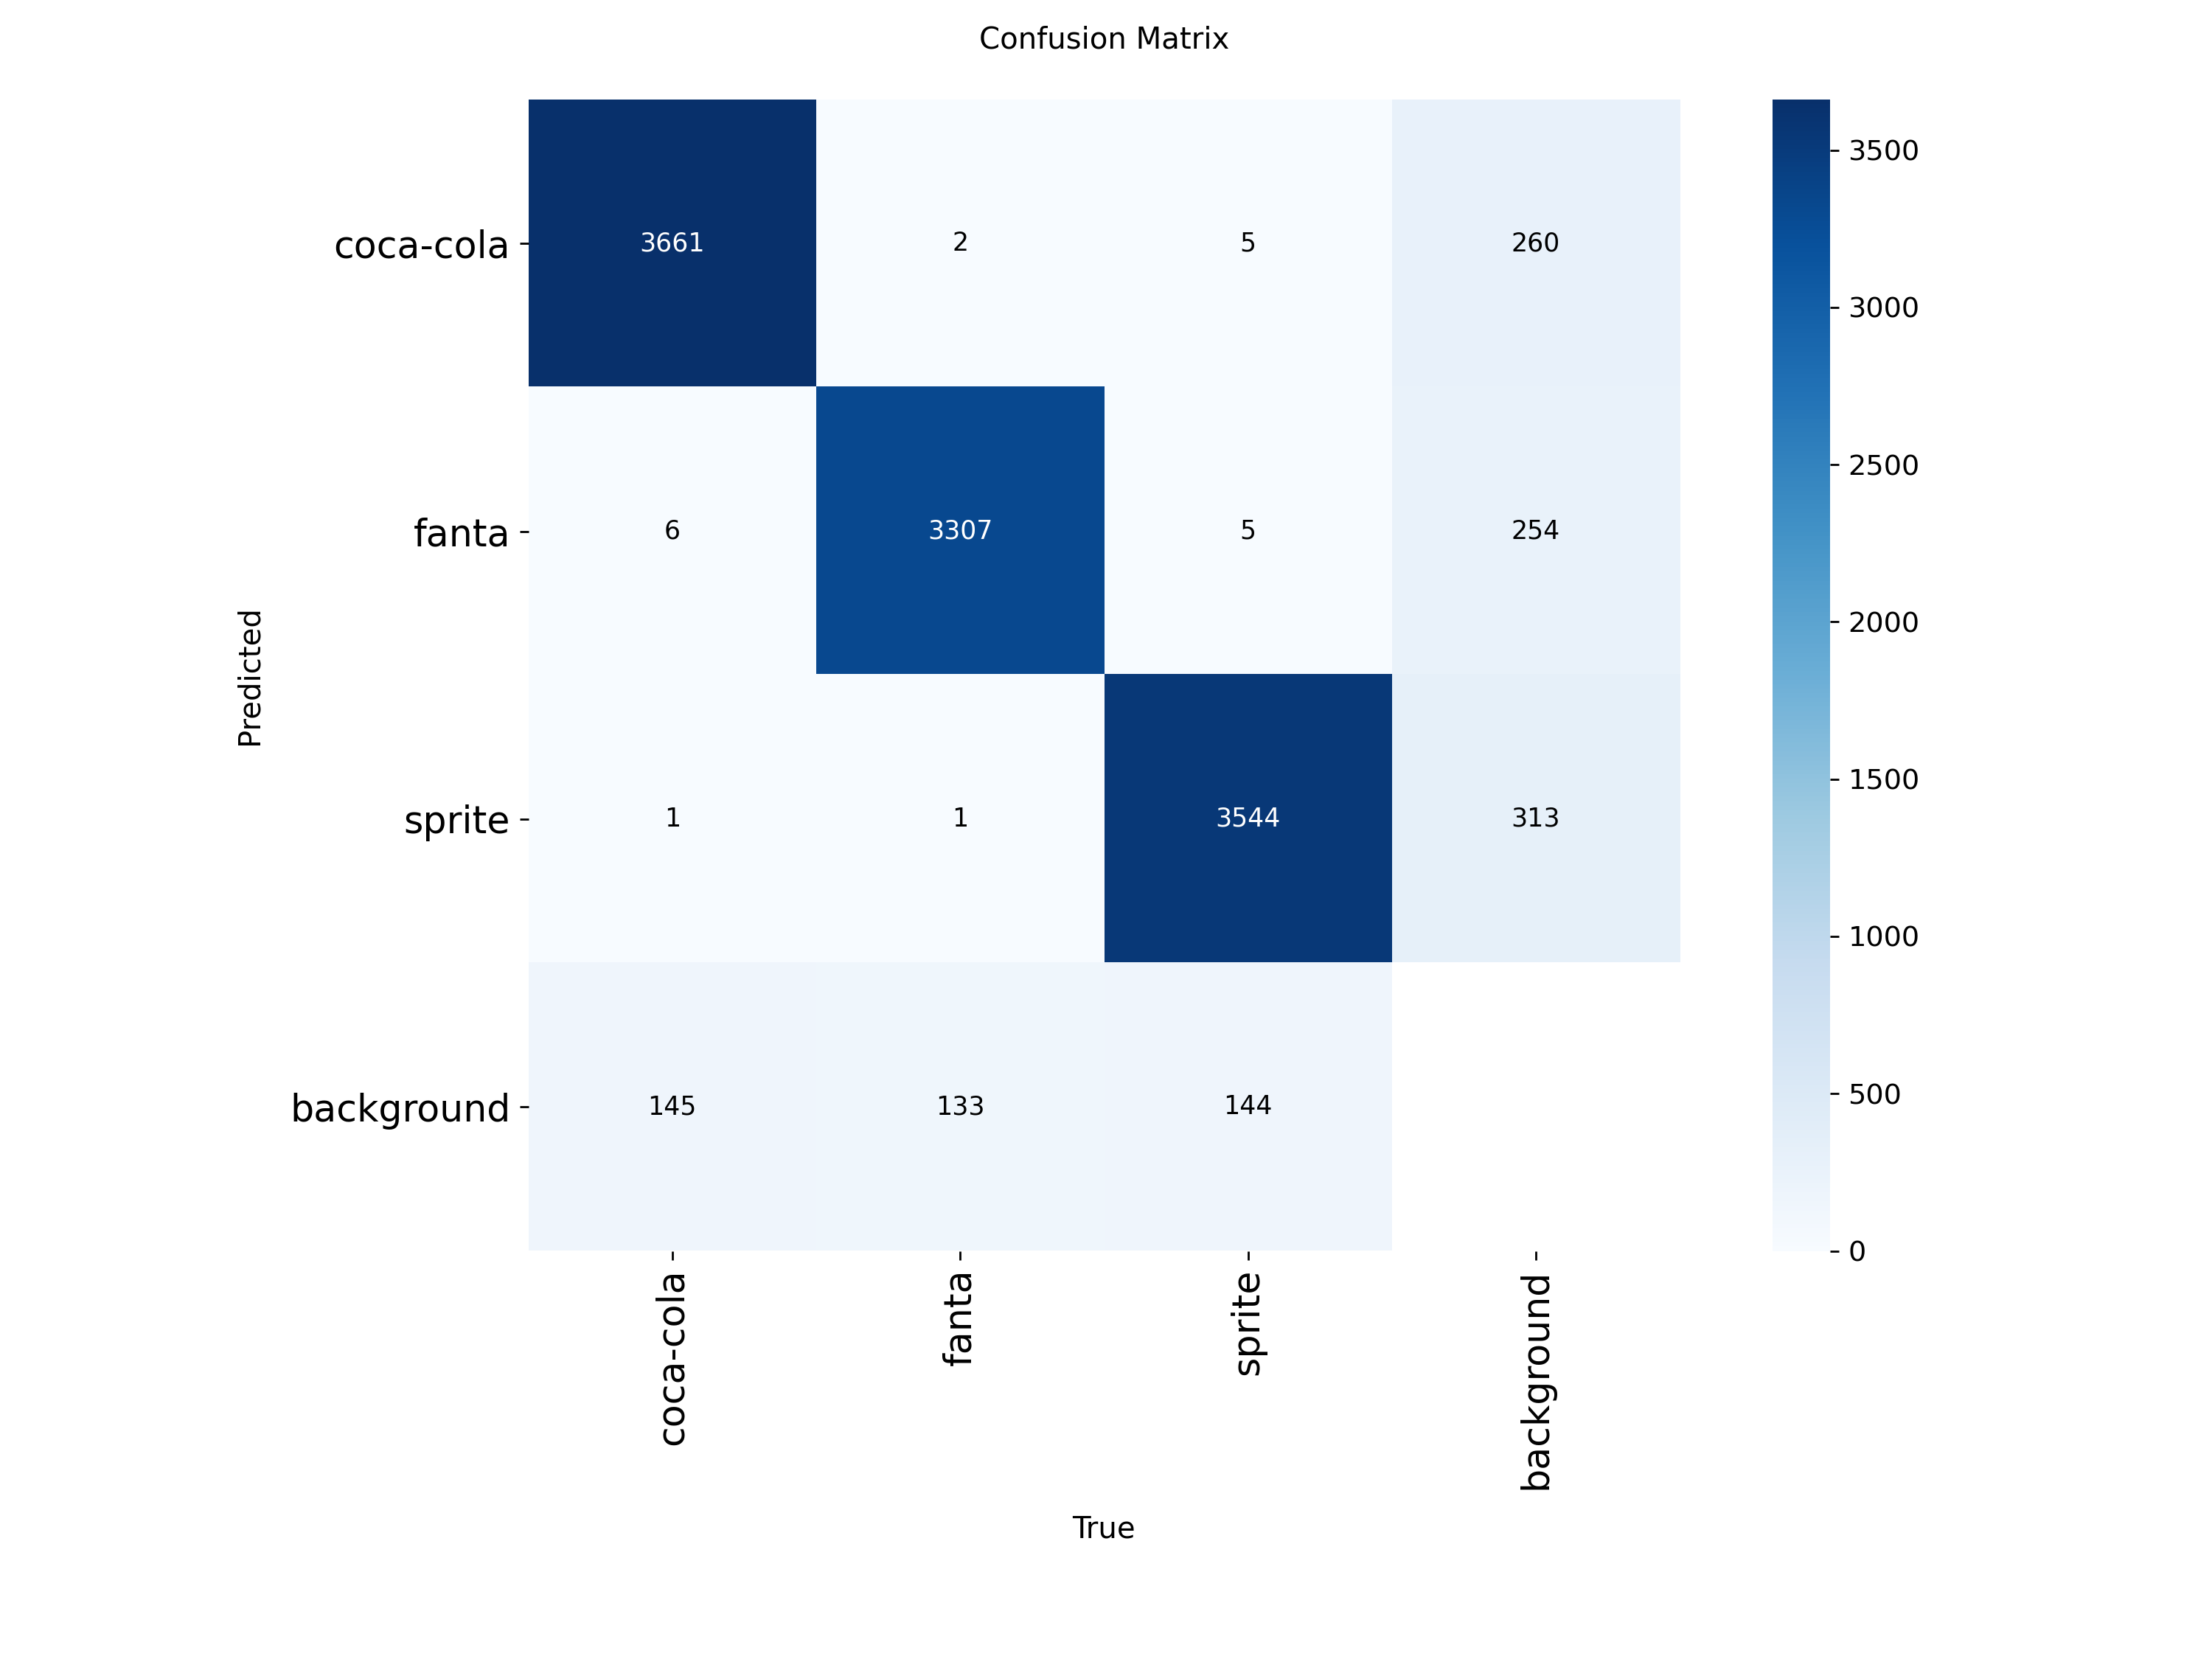


--- results.png ---


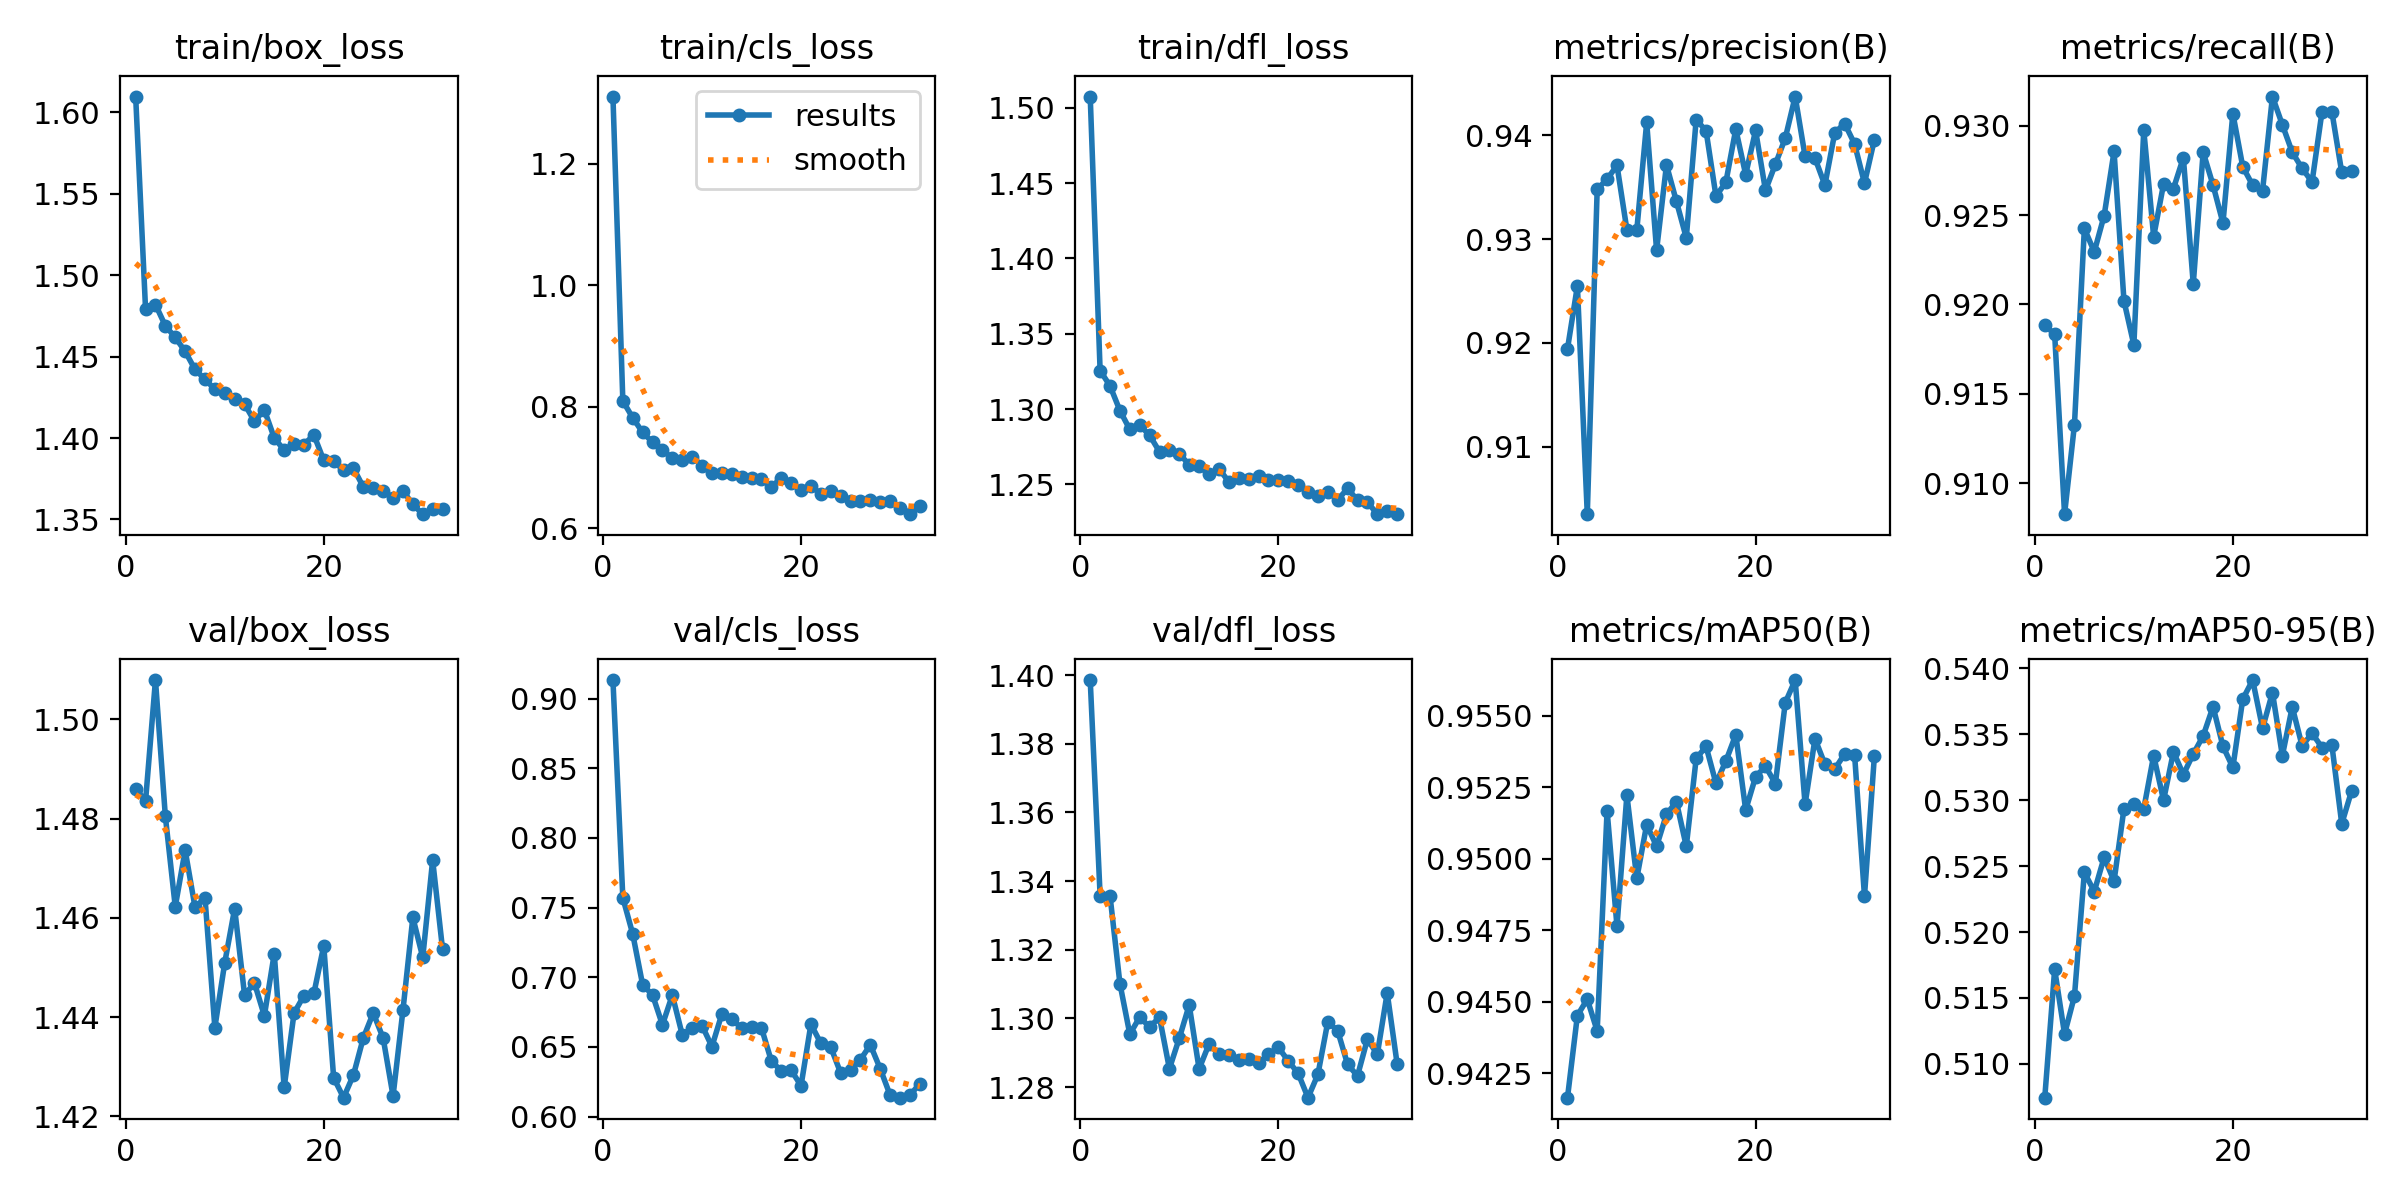


--- BoxPR_curve.png ---


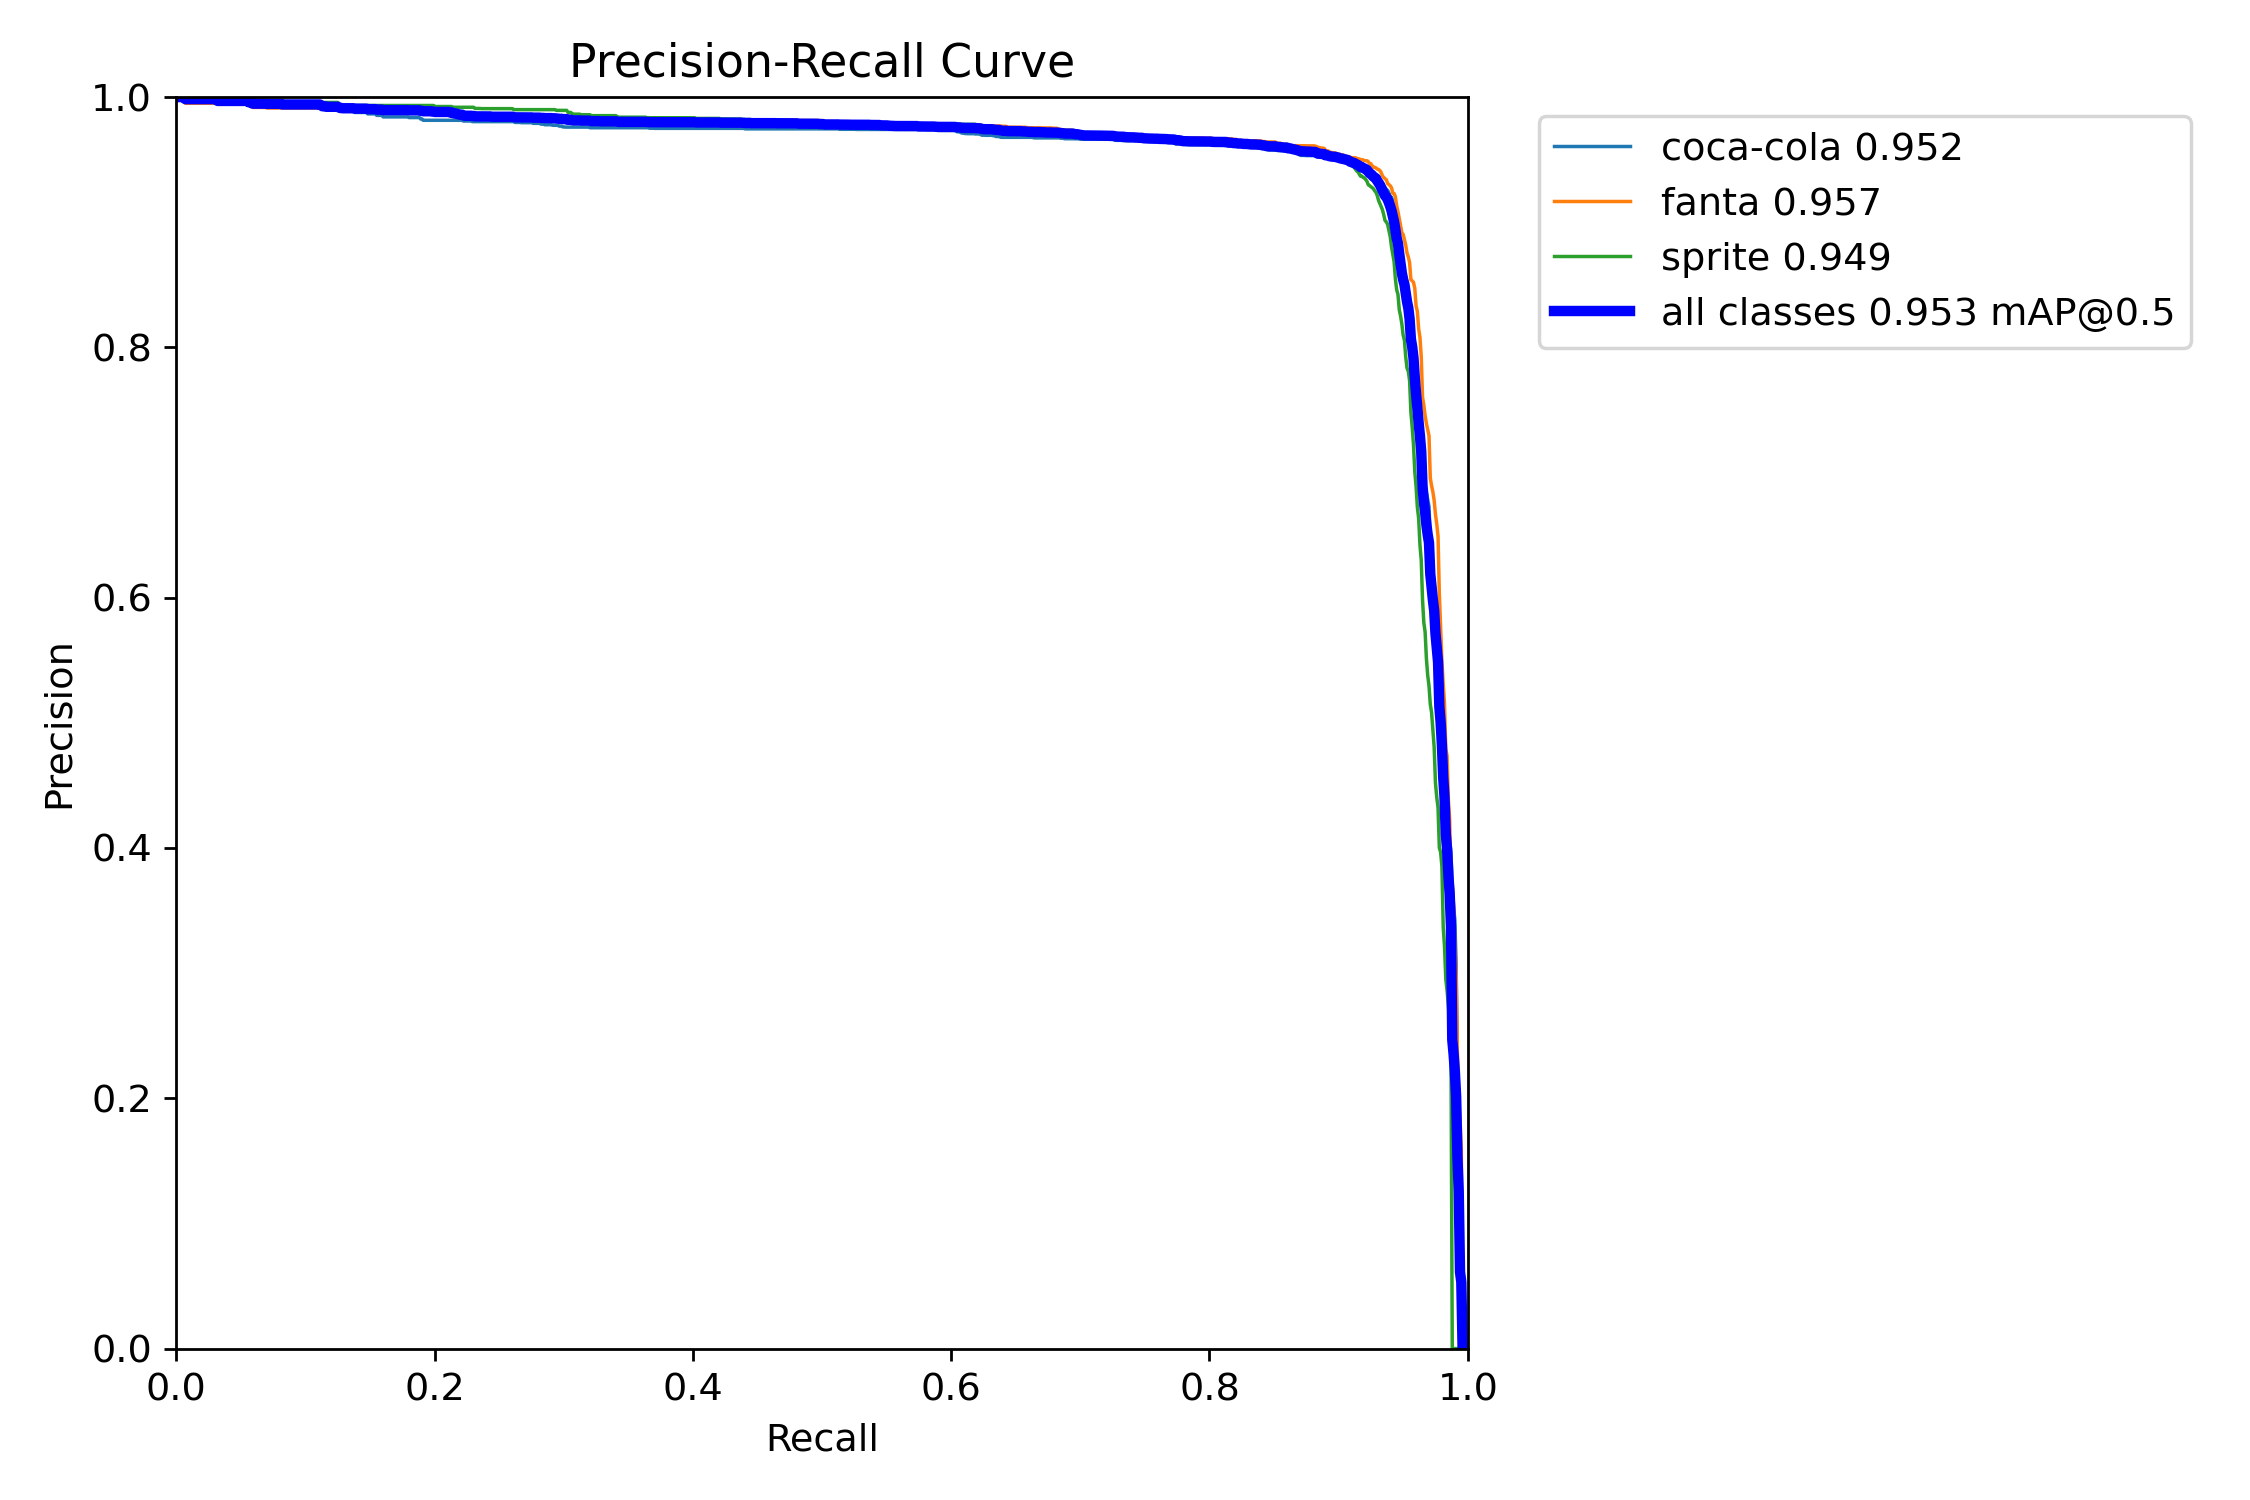


--- BoxF1_curve.png ---


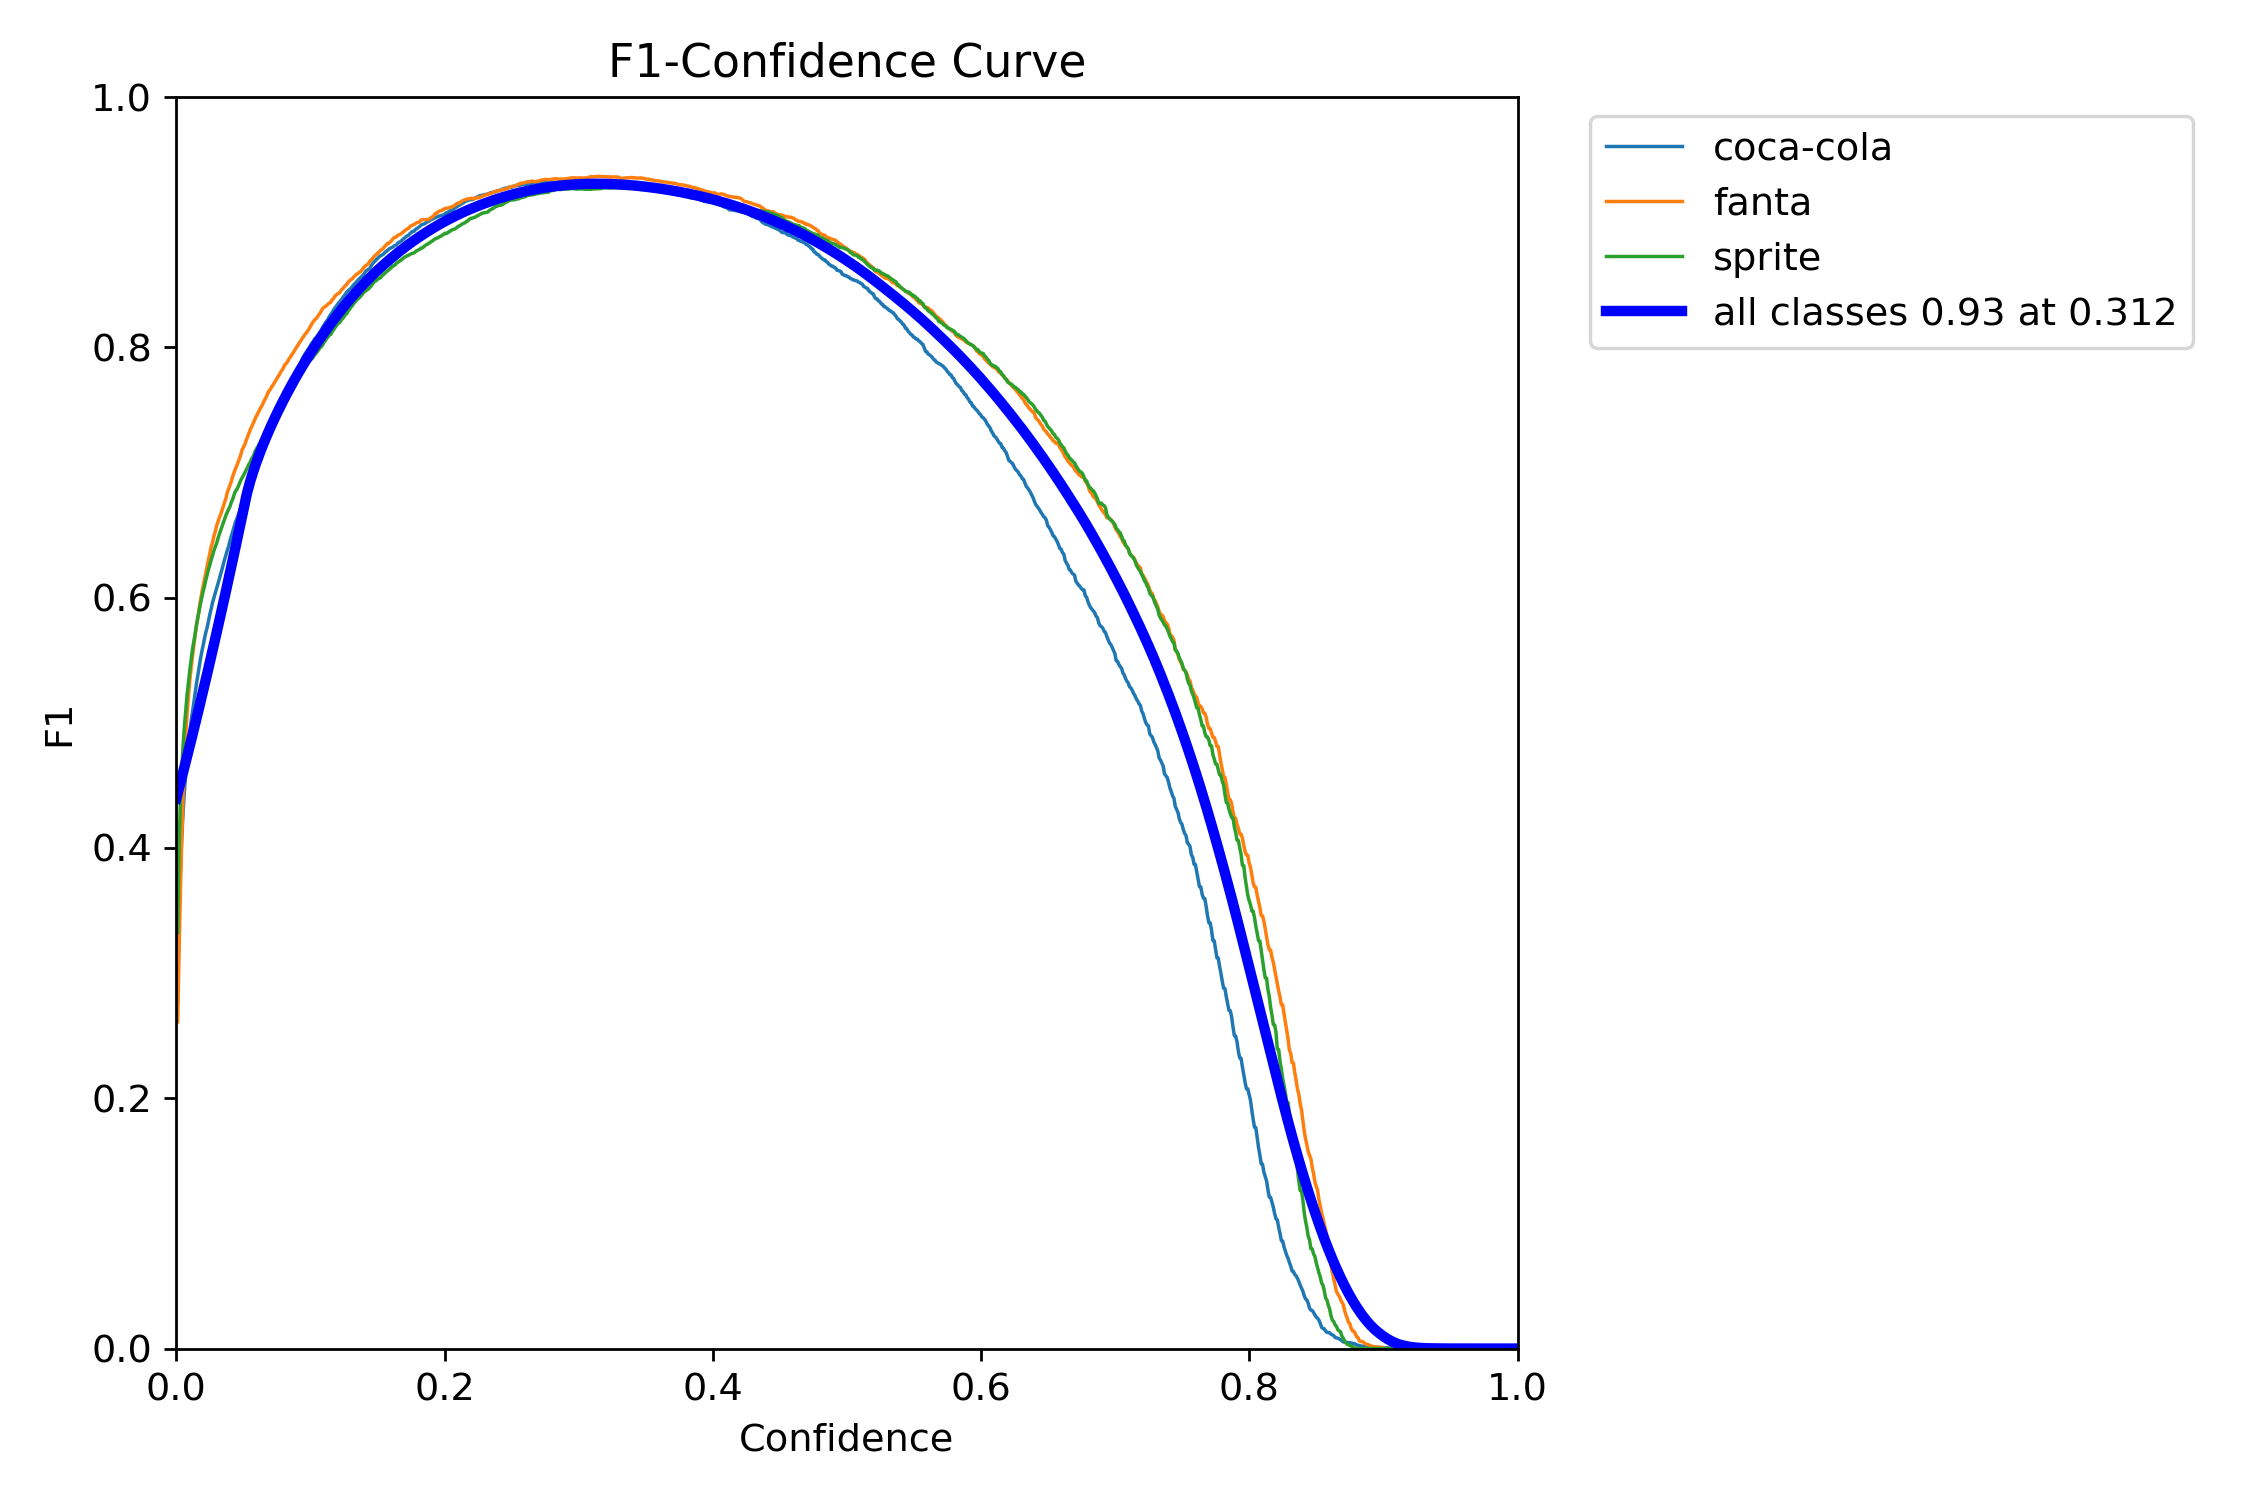

In [9]:
plot_files = [
    f"{RESULTS_DIR}/confusion_matrix.png",
    f"{RESULTS_DIR}/results.png",
    f"{RESULTS_DIR}/BoxPR_curve.png",
    f"{RESULTS_DIR}/BoxF1_curve.png",
]

for plot in plot_files:
    if Path(plot).exists():
        print(f"\n--- {Path(plot).name} ---")
        display(IPImage(plot, width=700))
    else:
        print(f"Not found: {plot}")

---
## Phase 5 — Test on a New Image

### Step 12 — Run detection on a shelf photo
Upload a shelf photo to Colab (folder icon on left → upload) then run this.

In [11]:
TEST_IMAGE = "test1.jpg"

if not Path(TEST_IMAGE).exists():
    print(f"Upload '{TEST_IMAGE}' to Colab first.")
else:
    detect_results = trained_model.predict(
        source  = TEST_IMAGE,
        conf    = 0.5,
        save    = True,
        project = "detections",
        name    = "ibrahim_test",
    )

    output_imgs = list(Path("detections/ibrahim_test").glob("*.jpg"))
    if not output_imgs:
        output_imgs = list(Path("detections/ibrahim_test").glob("*.png"))
    if output_imgs:
        display(IPImage(str(output_imgs[0]), width=700))

    result = detect_results[0]
    print(f"\nDetected {len(result.boxes)} objects:")
    for box in result.boxes:
        name = trained_model.names[int(box.cls)]
        conf = float(box.conf)
        print(f"  {name:<20} confidence: {conf*100:.1f}%")


image 1/1 /content/test1.jpg: 480x640 1 coca-cola, 6 fantas, 2 sprites, 43.9ms
Speed: 2.5ms preprocess, 43.9ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/detections/ibrahim_test-2

Detected 9 objects:
  fanta                confidence: 66.6%
  sprite               confidence: 65.4%
  fanta                confidence: 65.4%
  fanta                confidence: 63.3%
  fanta                confidence: 62.7%
  fanta                confidence: 57.1%
  coca-cola            confidence: 56.2%
  fanta                confidence: 51.4%
  sprite               confidence: 51.2%


---
## Phase 6 — Download and Report

### Step 13 — Download best.pt from Drive

In [12]:
from google.colab import files

if Path(BEST_MODEL).exists():
    files.download(BEST_MODEL)
else:
    print("File not found:", BEST_MODEL)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded. Send this file to Shameer.


### Step 14 — Download all results as ZIP

In [13]:
import zipfile

zip_path = "ShelfSight_YOLOv8s_Ibrahim_Results.zip"
results_path = Path(RESULTS_DIR)

if results_path.exists():
    with zipfile.ZipFile(zip_path, "w") as zf:
        for f in results_path.rglob("*"):
            if f.is_file():
                zf.write(f, f.relative_to(results_path))
    files.download(zip_path)
    print("Downloaded:", zip_path)
else:
    print("Results folder not found:", RESULTS_DIR)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: ShelfSight_YOLOv8s_Ibrahim_Results.zip


### Step 15 — Final scores for Shameer's comparison notebook

In [14]:
print("=" * 55)
print("IBRAHIM — SEND THESE NUMBERS TO SHAMEER")
print("=" * 55)
print(f"Model         : YOLOv8s (Model 2)")
print(f"mAP50         : {map50*100:.2f}%")
print(f"mAP50-95      : {map5095*100:.2f}%")
print(f"Precision     : {precision*100:.2f}%")
print(f"Recall        : {recall*100:.2f}%")
if training_time_mins > 0:
    print(f"Training time : {training_time_mins:.1f} minutes")
print(f"best.pt path  : {BEST_MODEL}")
print("=" * 55)

IBRAHIM — SEND THESE NUMBERS TO SHAMEER
Model         : YOLOv8s (Model 2)
mAP50         : 94.61%
mAP50-95      : 53.93%
Precision     : 93.79%
Recall        : 92.68%
best.pt path  : /content/drive/MyDrive/ShelfSight/YOLOv8s_Model2_Ibrahim/weights/best.pt


---
## Notes for the Viva

1. **Why YOLOv8s over YOLOv8n?** YOLOv8s has wider feature map channels — ~11M parameters vs 3.2M in YOLOv8n. This gives it more capacity to detect densely packed shelf products accurately.

2. **What did you contribute to the dataset?** You collected additional Nestlé-specific images added to the base Roboflow dataset. Mention where you got them and how many.

3. **What is fine-tuning?** Starting from COCO pre-trained weights (80 classes already learned) and updating them on our shelf dataset. Far faster and more accurate than training from scratch.

4. **How does your model compare to Shameer's?** Same dataset and training settings — only difference is model size. YOLOv8s should score 2–5% higher mAP but took longer to train.

5. **What would improve results further?** More images, higher epochs, or YOLOv8m (medium) — but at higher compute cost.